In [ ]:
https://github.com/Karanvaswani/Hamming-QPSK

FM Modulation Index (β): 5.00
FM Bandwidth (Carson's Rule): 12000 Hz

Output SNR after AM Demodulation: -5.68 dB
Output SNR after FM Demodulation: -2.30 dB


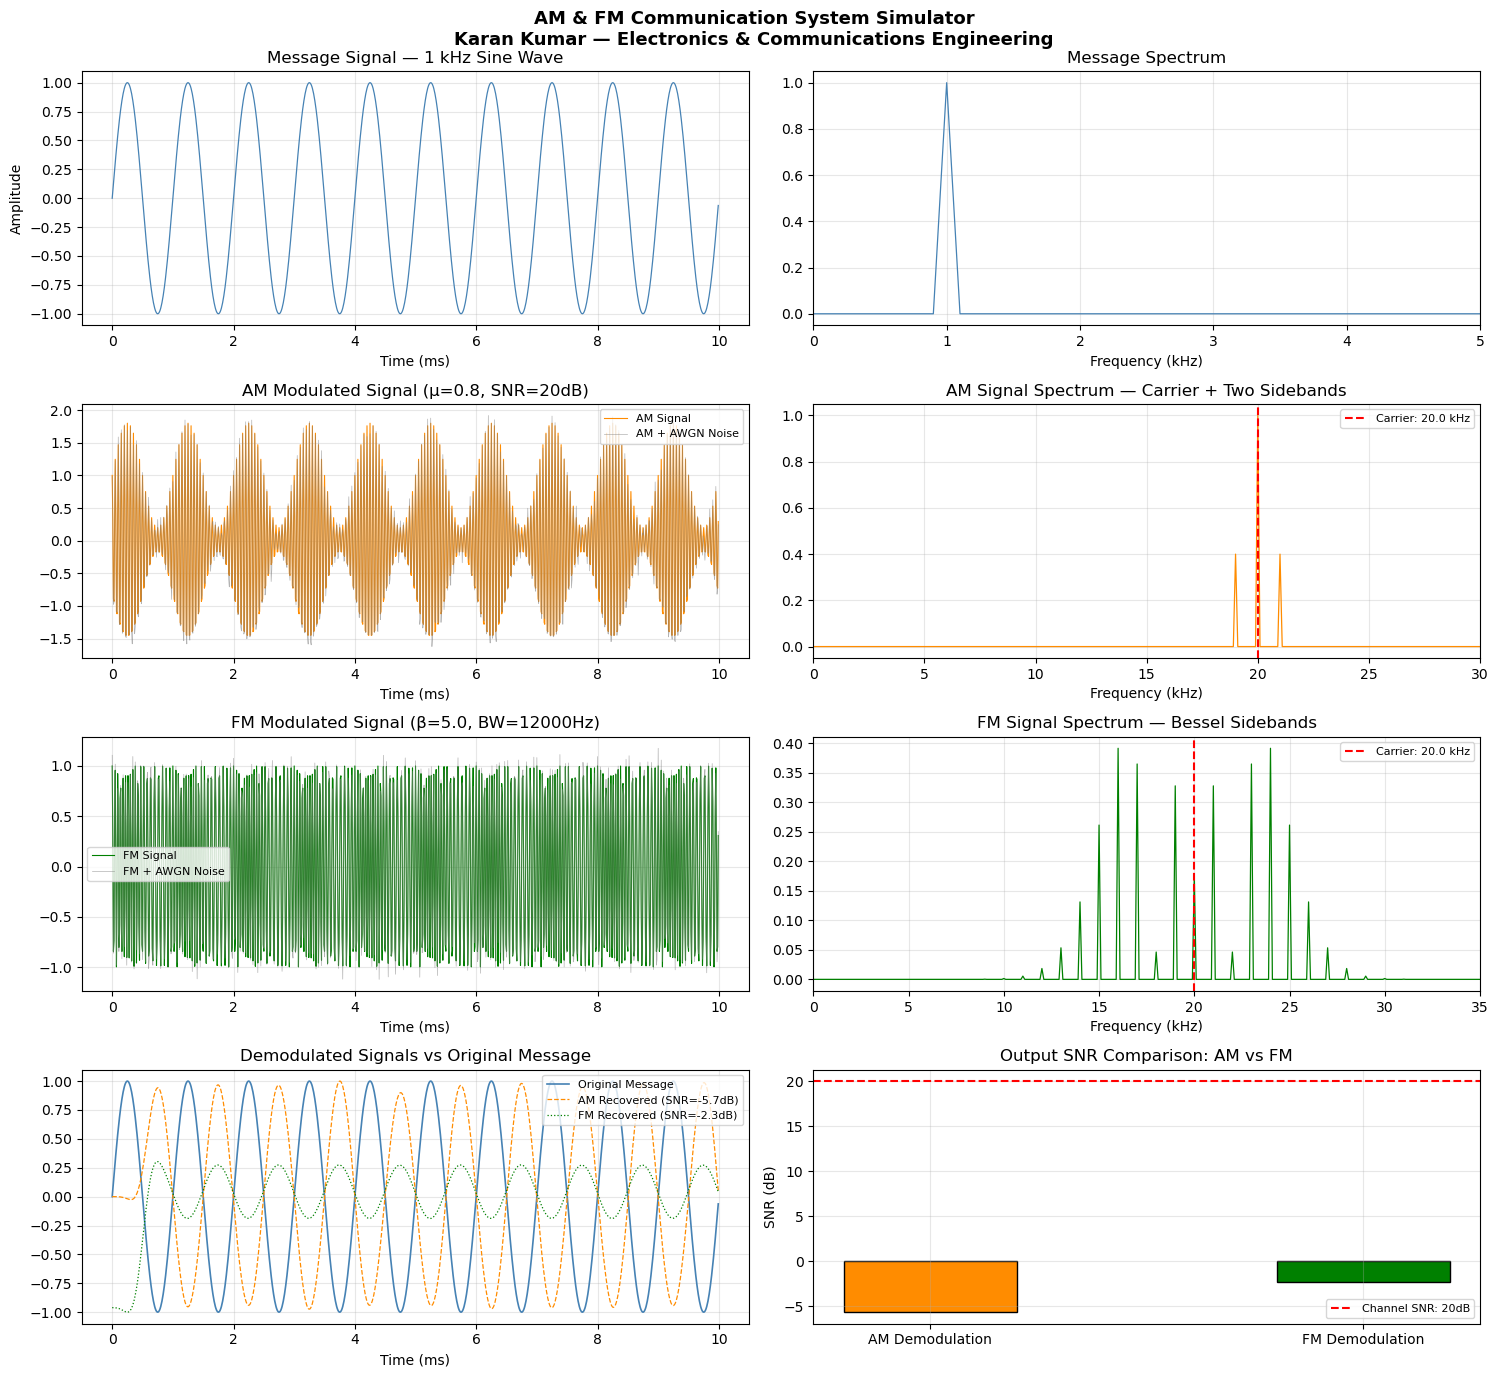


✅ Simulation complete! Plot saved.

📊 System Summary:
   Message Frequency     : 1000 Hz
   Carrier Frequency     : 20000 Hz
   AM Modulation Index   : 0.8
   FM Modulation Index β : 5.00
   FM Bandwidth (Carson) : 12000 Hz
   Channel SNR           : 20 dB
   AM Output SNR         : -5.68 dB
   FM Output SNR         : -2.30 dB


In [1]:
# ================================================================
# AM & FM Communication System Simulator
# Author: Karan Kumar
# Tools: Python, NumPy, SciPy, Matplotlib
# Description: Simulates a complete analog communication system
#              including AM/FM modulation, AWGN channel, 
#              demodulation, SNR analysis and FFT spectrum.
# Relevant to: Digital Communications, High-Frequency Systems,
#              Information Theory — MSc Electronics & Communications
#              University of Siena, Italy
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, hilbert, firwin
from scipy.fft import fft, fftfreq

# ================================================================
# GLOBAL PARAMETERS
# ================================================================
fs      = 100_000       # Sampling frequency: 100 kHz
T       = 0.01          # Duration: 10 ms
t       = np.arange(0, T, 1/fs)   # Time vector

fm      = 1_000         # Message signal frequency: 1 kHz
fc_am   = 20_000        # AM carrier frequency: 20 kHz
fc_fm   = 20_000        # FM carrier frequency: 20 kHz
kf      = 5_000         # FM frequency deviation constant (Hz/V)
Am      = 1.0           # Message amplitude
Ac      = 1.0           # Carrier amplitude
mu      = 0.8           # AM modulation index (0 < mu <= 1)
SNR_dB  = 20            # Channel SNR in dB

# ================================================================
# MODULE 1: MESSAGE SIGNAL
# ================================================================
message = Am * np.sin(2 * np.pi * fm * t)

# ================================================================
# MODULE 2: AM MODULATION
# AM(t) = Ac * [1 + mu * m(t)] * cos(2*pi*fc*t)
# ================================================================
carrier_am  = Ac * np.cos(2 * np.pi * fc_am * t)
am_signal   = Ac * (1 + mu * message) * np.cos(2 * np.pi * fc_am * t)

# ================================================================
# MODULE 3: FM MODULATION
# FM(t) = Ac * cos(2*pi*fc*t + 2*pi*kf * integral(m(t)))
# ================================================================
integral_msg    = np.cumsum(message) / fs   # Numerical integration
fm_signal       = Ac * np.cos(2 * np.pi * fc_fm * t + 2 * np.pi * kf * integral_msg)

# Modulation index and bandwidth (Carson's rule)
modulation_index = kf / fm
bandwidth_carson = 2 * (kf + fm)
print(f"FM Modulation Index (β): {modulation_index:.2f}")
print(f"FM Bandwidth (Carson's Rule): {bandwidth_carson} Hz")

# ================================================================
# MODULE 4: AWGN NOISE CHANNEL
# ================================================================
def add_awgn(signal, snr_db):
    snr_linear  = 10 ** (snr_db / 10)
    power_sig   = np.mean(signal ** 2)
    power_noise = power_sig / snr_linear
    noise       = np.sqrt(power_noise) * np.random.randn(len(signal))
    return signal + noise, noise

am_noisy, noise_am = add_awgn(am_signal, SNR_dB)
fm_noisy, noise_fm = add_awgn(fm_signal, SNR_dB)

# ================================================================
# MODULE 5: AM DEMODULATION (Envelope Detection via Hilbert)
# ================================================================
def am_demodulate(received, fc, fs):
    analytic    = hilbert(received)              # Analytic signal
    envelope    = np.abs(analytic)               # Envelope = |H{x}|
    envelope   -= np.mean(envelope)             # Remove DC offset
    # Low-pass filter to recover message
    b = firwin(101, fm * 2 / (fs / 2), window='hamming')
    recovered = lfilter(b, 1.0, envelope)
    return recovered, envelope

am_recovered, am_envelope = am_demodulate(am_noisy, fc_am, fs)

# ================================================================
# MODULE 6: FM DEMODULATION (Instantaneous Frequency)
# ================================================================
def fm_demodulate(received, fs):
    analytic    = hilbert(received)
    phase       = np.unwrap(np.angle(analytic))  # Unwrapped phase
    inst_freq   = np.diff(phase) / (2 * np.pi) * fs  # d(phase)/dt
    inst_freq   = np.append(inst_freq, inst_freq[-1]) # Fix length
    # Low-pass filter
    b = firwin(101, fm * 2 / (fs / 2), window='hamming')
    recovered = lfilter(b, 1.0, inst_freq)
    recovered -= np.mean(recovered)
    recovered /= (np.max(np.abs(recovered)) + 1e-10)  # Normalize
    return recovered

fm_recovered = fm_demodulate(fm_noisy, fs)

# ================================================================
# MODULE 7: SNR CALCULATION
# ================================================================
def calculate_snr(original, recovered):
    error       = original - recovered
    power_sig   = np.mean(original ** 2)
    power_err   = np.mean(error ** 2)
    snr         = 10 * np.log10(power_sig / (power_err + 1e-10))
    return snr

snr_am = calculate_snr(message, am_recovered / (np.max(np.abs(am_recovered)) + 1e-10))
snr_fm = calculate_snr(message, fm_recovered)
print(f"\nOutput SNR after AM Demodulation: {snr_am:.2f} dB")
print(f"Output SNR after FM Demodulation: {snr_fm:.2f} dB")

# ================================================================
# MODULE 8: FFT SPECTRUM FUNCTION
# ================================================================
def compute_spectrum(signal, fs):
    N       = len(signal)
    f       = fftfreq(N, 1/fs)
    X       = np.abs(fft(signal)) / N * 2
    pos     = f >= 0
    return f[pos], X[pos]

# ================================================================
# MODULE 9: PLOTTING (4x2 Grid)
# ================================================================
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
fig.suptitle('AM & FM Communication System Simulator\n'
             'Karan Kumar — Electronics & Communications Engineering',
             fontsize=13, fontweight='bold')

# Row 1: Message signal + its spectrum
axes[0,0].plot(t*1000, message, color='steelblue', lw=0.9)
axes[0,0].set_title('Message Signal — 1 kHz Sine Wave')
axes[0,0].set_xlabel('Time (ms)'); axes[0,0].set_ylabel('Amplitude')
axes[0,0].grid(True, alpha=0.3)

f_m, X_m = compute_spectrum(message, fs)
axes[0,1].plot(f_m/1000, X_m, color='steelblue', lw=0.9)
axes[0,1].set_title('Message Spectrum')
axes[0,1].set_xlabel('Frequency (kHz)'); axes[0,1].set_xlim([0, 5])
axes[0,1].grid(True, alpha=0.3)

# Row 2: AM signal + noisy
axes[1,0].plot(t*1000, am_signal, color='darkorange', lw=0.8, label='AM Signal')
axes[1,0].plot(t*1000, am_noisy,  color='gray', lw=0.5, alpha=0.6, label='AM + AWGN Noise')
axes[1,0].set_title(f'AM Modulated Signal (μ={mu}, SNR={SNR_dB}dB)')
axes[1,0].set_xlabel('Time (ms)'); axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

f_am, X_am = compute_spectrum(am_signal, fs)
axes[1,1].plot(f_am/1000, X_am, color='darkorange', lw=0.9)
axes[1,1].set_title('AM Signal Spectrum — Carrier + Two Sidebands')
axes[1,1].set_xlabel('Frequency (kHz)'); axes[1,1].set_xlim([0, 30])
axes[1,1].axvline(x=fc_am/1000, color='red', ls='--', label=f'Carrier: {fc_am/1000} kHz')
axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)

# Row 3: FM signal + noisy
axes[2,0].plot(t*1000, fm_signal, color='green', lw=0.8, label='FM Signal')
axes[2,0].plot(t*1000, fm_noisy,  color='gray', lw=0.5, alpha=0.6, label='FM + AWGN Noise')
axes[2,0].set_title(f'FM Modulated Signal (β={modulation_index:.1f}, BW={bandwidth_carson}Hz)')
axes[2,0].set_xlabel('Time (ms)'); axes[2,0].legend(fontsize=8)
axes[2,0].grid(True, alpha=0.3)

f_fm, X_fm = compute_spectrum(fm_signal, fs)
axes[2,1].plot(f_fm/1000, X_fm, color='green', lw=0.9)
axes[2,1].set_title('FM Signal Spectrum — Bessel Sidebands')
axes[2,1].set_xlabel('Frequency (kHz)'); axes[2,1].set_xlim([0, 35])
axes[2,1].axvline(x=fc_fm/1000, color='red', ls='--', label=f'Carrier: {fc_fm/1000} kHz')
axes[2,1].legend(fontsize=8); axes[2,1].grid(True, alpha=0.3)

# Row 4: Recovered signals comparison
norm_am = am_recovered / (np.max(np.abs(am_recovered)) + 1e-10)
axes[3,0].plot(t*1000, message,  color='steelblue', lw=1.2, label='Original Message')
axes[3,0].plot(t*1000, norm_am,  color='darkorange', lw=0.9, ls='--', label=f'AM Recovered (SNR={snr_am:.1f}dB)')
axes[3,0].plot(t*1000, fm_recovered, color='green', lw=0.9, ls=':', label=f'FM Recovered (SNR={snr_fm:.1f}dB)')
axes[3,0].set_title('Demodulated Signals vs Original Message')
axes[3,0].set_xlabel('Time (ms)'); axes[3,0].legend(fontsize=8)
axes[3,0].grid(True, alpha=0.3)

# SNR Comparison bar chart
axes[3,1].bar(['AM Demodulation', 'FM Demodulation'],
              [snr_am, snr_fm],
              color=['darkorange', 'green'], width=0.4, edgecolor='black')
axes[3,1].set_title('Output SNR Comparison: AM vs FM')
axes[3,1].set_ylabel('SNR (dB)')
axes[3,1].axhline(y=SNR_dB, color='red', ls='--', label=f'Channel SNR: {SNR_dB}dB')
axes[3,1].legend(fontsize=8); axes[3,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('communication_system_simulator.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Simulation complete! Plot saved.")
print(f"\n📊 System Summary:")
print(f"   Message Frequency     : {fm} Hz")
print(f"   Carrier Frequency     : {fc_am} Hz")
print(f"   AM Modulation Index   : {mu}")
print(f"   FM Modulation Index β : {modulation_index:.2f}")
print(f"   FM Bandwidth (Carson) : {bandwidth_carson} Hz")
print(f"   Channel SNR           : {SNR_dB} dB")
print(f"   AM Output SNR         : {snr_am:.2f} dB")
print(f"   FM Output SNR         : {snr_fm:.2f} dB")